# Exam Project

Import and set magics:

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import Problem1, Problem2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Problem 1

### Question 1.a

## Problem 2

### Question 2.1

We start by finding the steady state analytically and confirm it numerically with a root-finder. We then simulate the baseline model with a constant savings rate, $s_t = \bar{s}$, and plot the paths for $s_t$, $k_t$ and $c_t$. Finally, we test the simulator with two cases where the answer is known in advance.

In [30]:
from SolowModel import SolowModelClass
import numpy as np
import matplotlib.pyplot as plt

# Create the model with the calibration from the exam
model = SolowModelClass()

# Analytical steady state for s = s_bar
k_star, y_star, c_star = model.steady_state()
print(f'analytical: k* = {k_star:.4f}, y* = {y_star:.4f}, c* = {c_star:.4f}')

# Confirm k* with a root-finder
k_star_num = model.solve_steady_state()
print(f'numerical:  k* = {k_star_num:.4f}')

assert np.isclose(k_star, k_star_num), 'analytical and numerical steady state do not agree'

analytical: k* = 0.7607, y* = 0.9129, c* = 0.6847
numerical:  k* = 0.7607


It has been shown, that the analytical and numerical steady state agree - as expected. Next, we will simulate the baseline economy for $T=100$ periods starting from $k_0=0.10$, using the constant savings rate $\bar{s}=0.25$.

c_0     = 0.3481
c_T-1   = 0.6847
k_T-1   = 0.7607


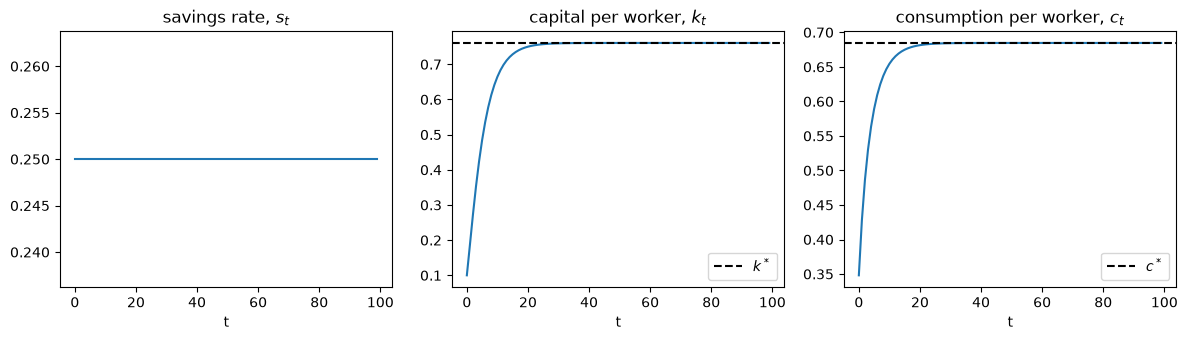

In [31]:
# Simulate the baseline with a constant savings rate
par = model.par
sim_baseline = model.simulate(s=par.s_bar)

# Report key numbers
print(f'c_0     = {sim_baseline.c[0]:.4f}')
print(f'c_T-1   = {sim_baseline.c[-1]:.4f}')
print(f'k_T-1   = {sim_baseline.k[-1]:.4f}')

# Plot s_t, k_t and c_t in three panels
t = np.arange(par.T)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(t, sim_baseline.s)
axes[0].set_title('savings rate, $s_t$')
axes[0].set_xlabel('t')

axes[1].plot(t, sim_baseline.k)
axes[1].axhline(k_star, ls='--', color='black', label='$k^*$')
axes[1].set_title('capital per worker, $k_t$')
axes[1].set_xlabel('t')
axes[1].legend()

axes[2].plot(t, sim_baseline.c)
axes[2].axhline(c_star, ls='--', color='black', label='$c^*$')
axes[2].set_title('consumption per worker, $c_t$')
axes[2].set_xlabel('t')
axes[2].legend()

fig.tight_layout()
plt.show()

As seen by the plots, capital converges monotonically to $k^*$, and consumption converges to $c^*$, as the constant savings rate implies. We now test the simulator agianst two cases where the outcome is known analytically: (i) Starting exactly at the steady state should leave $k_t$ unchanged, and (ii) a zero savings rate should make capital decay geometrically at rate $(1-\delta)$.

In [32]:
# Test 1: starting at k* with s = s_bar should stay at k*
sim_at_star = model.simulate(s=par.s_bar, k0=k_star)
assert np.allclose(sim_at_star.k, k_star), 'economy starting at k* should remain there'

# Test 2: with s = 0, capital should decay as k_t = (1-delta)^t * k0
sim_zero_s = model.simulate(s=0.0)
k_analytical = (1 - par.delta)**np.arange(par.T) * par.k0
assert np.allclose(sim_zero_s.k, k_analytical), 'capital path with s=0 does not match analytical decay'

print('both assert tests passed')

both assert tests passed


### Question 2.2

We now let the savings rate vary over time according to $s_tt=\bar{s} + (s_0-\bar{s})\phi^t$, and simulate the model for the four given combinations of $(s_0,\phi)$, together with the baseline.

In [33]:
import copy

# Simulate baseline (again, to be safe) and copy the result out
sim_baseline = copy.deepcopy(model.simulate(s=par.s_bar))

# Simulate each combination, copying each result out of the shared sim object
combos = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]
sims = {}
for s0, phi in combos:
    s_vec = model.s_path(s0, phi)
    sims[(s0, phi)] = copy.deepcopy(model.simulate(s=s_vec))

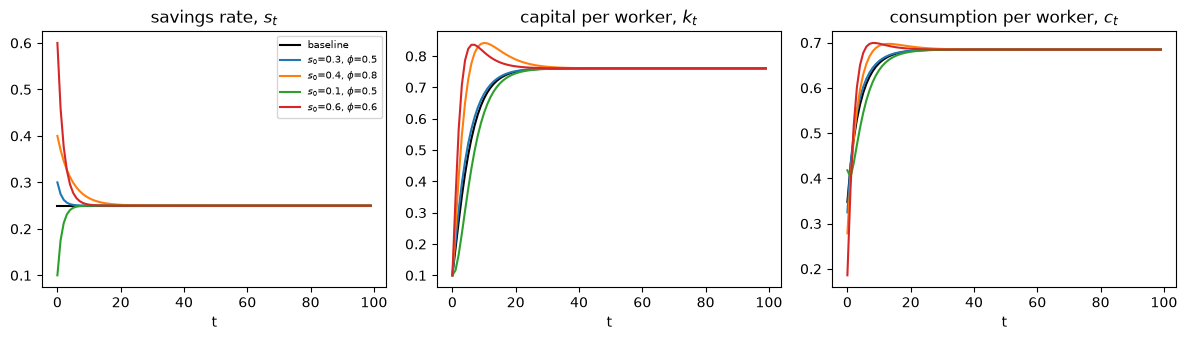

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(t, sim_baseline.s, color='black', label='baseline')
axes[1].plot(t, sim_baseline.k, color='black', label='baseline')
axes[2].plot(t, sim_baseline.c, color='black', label='baseline')

for (s0, phi), sim in sims.items():
    label = f'$s_0$={s0}, $\\phi$={phi}'
    axes[0].plot(t, sim.s, label=label)
    axes[1].plot(t, sim.k, label=label)
    axes[2].plot(t, sim.c, label=label)

axes[0].set_title('savings rate, $s_t$')
axes[1].set_title('capital per worker, $k_t$')
axes[2].set_title('consumption per worker, $c_t$')
for ax in axes:
    ax.set_xlabel('t')
axes[0].legend(fontsize=7)

fig.tight_layout()
plt.show()

As seen by the plots, all four combinations converge to the same steady state $k_{T-1}$ as the baseline, since $s_t \to \bar{s}$ as $t\to\infty$ regardless of $s_0$ and $\phi$. The long-run savings rate is the same in every case.

$s_0$ sets the starting point of the savings rate: A high $s_0$ means high initial investment and a faster initial buildup of capital, while a low $s_0$ means low initial investment and a slower start, temporarily below the baseline path.

$\phi$ governs the speed at which $s_t$ returns to $\bar{s}$: A high $\phi$ (close to 1) makes the deviation from $\bar{s}$ persist for a long time, while a lower $\phi$ means the savings rate reverts to $\bar{s}$ quickly, so the path looks close to the baseline after just a few periods.